# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# Import Dataset
df = pd.read_csv('social_media_screentime_mental_health_2026.csv')
df.head()  # preview the first 5 rows

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [9]:
# Step 2: Initialize Parameters
def initialize_parameters():
    # Seed the random number generator for reproducibility
    np.random.seed(1)
    # Initialize weights and biases for the first layer (3 neurons, 3 inputs)
    W1 = np.random.randn(3, 3) * 0.01
    b1 = np.zeros((3, 1))
    # Initialize weights and biases for the second layer (10 neurons, 3 inputs)
    W2 = np.random.randn(10, 3) * 0.01
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

In [10]:
# Function to print the parameters in a pretty format (optional)
def print_parameters(W1, b1, W2, b2):
    print("W1 (weights for the first layer):")
    print(W1)
    print("\nb1 (biases for the first layer):")
    print(b1)
    print("\nW2 (weights for the second layer):")
    print(W2)
    print("\nb2 (biases for the second layer):")
    print(b2)

# Initialize parameters
W1, b1, W2, b2 = initialize_parameters()

# Print parameters in a pretty format
print_parameters(W1, b1, W2, b2)

W1 (weights for the first layer):
[[ 0.01624345 -0.00611756 -0.00528172]
 [-0.01072969  0.00865408 -0.02301539]
 [ 0.01744812 -0.00761207  0.00319039]]

b1 (biases for the first layer):
[[0.]
 [0.]
 [0.]]

W2 (weights for the second layer):
[[-0.0024937   0.01462108 -0.02060141]
 [-0.00322417 -0.00384054  0.01133769]
 [-0.01099891 -0.00172428 -0.00877858]
 [ 0.00042214  0.00582815 -0.01100619]
 [ 0.01144724  0.00901591  0.00502494]
 [ 0.00900856 -0.00683728 -0.0012289 ]
 [-0.00935769 -0.00267888  0.00530355]
 [-0.00691661 -0.00396754 -0.00687173]
 [-0.00845206 -0.00671246 -0.00012665]
 [-0.0111731   0.00234416  0.01659802]]

b2 (biases for the second layer):
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [11]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0



In [12]:
# Step 4: Forward Propagation
def forward_propagation(X, W1, b1, W2, b2):
    # Compute linear combination for first layer
    Z1 = np.dot(W1, X) + b1
    # Apply ReLU activation function
    A1 = relu(Z1)
    # Compute linear combination for second layer
    Z2 = np.dot(W2, A1) + b2
    # Apply sigmoid activation function
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

In [13]:
# Step 5: Compute Cost
def compute_cost(A2, Y):
    # Number of examples
    m = Y.shape[0]
    # Compute categorical cross-entropy cost
    cost = -1/m * np.sum(Y * np.log(A2))
    return np.squeeze(cost)

In [14]:
# Step 6: Backward Propagation
def backward_propagation(X, Y, Z1, A1, A2, W2):
    # Number of examples
    m = X.shape[1]

    # Compute gradient of cost with respect to Z2
    dZ2 = A2 - Y
    # Compute gradient of cost with respect to W2
    dW2 = 1/m * np.dot(dZ2, A1.T)
    # Compute gradient of cost with respect to b2
    db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)

    # Compute gradient of cost with respect to A1
    dA1 = np.dot(W2.T, dZ2)
    # Compute gradient of cost with respect to Z1 using ReLU derivative
    dZ1 = dA1 * relu_derivative(Z1)
    # Compute gradient of cost with respect to W1
    dW1 = 1/m * np.dot(dZ1, X.T)
    # Compute gradient of cost with respect to b1
    db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

In [15]:
# Step 7: Update Parameters in gradient descent
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    # Update weights and biases for the first layer
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    # Update weights and biases for the second layer
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    return W1, b1, W2, b2

In [16]:
# Step 8: Train the Neural Network
def model(X, Y, learning_rate=0.01, num_iterations=10000):
    # Initialize parameters
    W1, b1, W2, b2 = initialize_parameters()

    # Gradient descent loop
    for i in range(num_iterations):
        # Forward propagation
        Z1, A1, Z2, A2 = forward_propagation(X, W1, b1, W2, b2)
        # Compute cost
        cost = compute_cost(A2, Y)
        # Backward propagation
        dW1, db1, dW2, db2 = backward_propagation(X, Y, Z1, A1, A2, W2)
        # Update parameters
        W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

        # Print cost every 1000 iterations
        if i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost}")

    return W1, b1, W2, b2

In [17]:
# Step 10: Make a prediction
def predict(X, W1, b1, W2, b2):
    # Forward propagation
    _, _, _, A2 = forward_propagation(X, W1, b1, W2, b2)
    # Pick the class with the highest probability for each example
    predictions = np.argmax(A2, axis=0)
    return predictions


In [18]:
# Step 11: Evaluate the Model
def evaluate_model(X, Y, W1, b1, W2, b2):
    predictions = predict(X, W1, b1, W2, b2)
    accuracy = np.mean(predictions == Y) * 100
    return accuracy

      platforms_used_count  life_satisfaction_1to10  daily_notifications
6500                     1                        6                  100
2944                     5                        9                   15
2024                     2                        4                   93
263                      4                        2                   64
4350                     6                        5                   68
3424                     3                        7                   63
6748                     5                        8                   82
6215                     5                        7                   13
6362                     3                        5                   60
5589                     1                        5                   51
(10, 10)
Cost after iteration 0: 0.6932808883001083
Cost after iteration 1000: 1.7480434176832924
Cost after iteration 2000: 1.7480673457184748
Cost after iteration 3000: 1.7480673485457503
Cost af

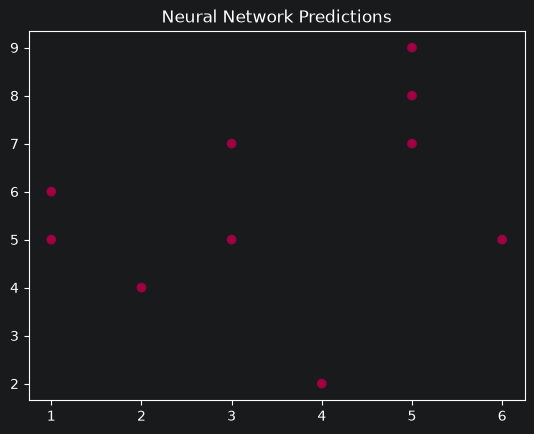

In [20]:
# Prediction from imported dataset

# Take a random sample of n rows
sample = df.sample(n=10, random_state=42)

# Choosing target and input columns
target_column = 'loneliness_1to10'
input_columns = ['platforms_used_count', 'life_satisfaction_1to10', 'daily_notifications']

X = sample[input_columns]
print(X)
X = X.T
X = X.astype(int).to_numpy()

num_classes = 10  # ratings 1 to 10
Y_labels = sample[target_column].astype(int).to_numpy() - 1  # shift to 0-indexed (0-9)
Y = np.eye(num_classes)[Y_labels].T
print(Y.shape)

# Train the model
W1, b1, W2, b2 = model(X, Y, learning_rate=0.1, num_iterations=100000)

predictions = predict(X, W1, b1, W2, b2)
print(predictions)

# Plot the results
plt.scatter(X[0, :], X[1, :], c=predictions, cmap=plt.cm.Spectral)
plt.title("Neural Network Predictions")
plt.show()
